# Autoencoder model

In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pcn
from hpc.models import AutoEncoder
import numpy as np
from hpc import utils
from tqdm import tqdm
from pcn.models import PCModel
import torch.nn as nn
import matplotlib.pyplot as plt
from pcn import plotting, datasets

## Data

In [2]:
seed = 0

# dataset params
train_size = None
test_size = None
normalize = True
batch_size = 64

# inference params
mu_dt = 0.01
n_test_iters = 200
n_max_iters = 20000
step_tolerance = 1e-5
init_std = 0.01
fixed_preds_test = False

# model params
use_bias = True
kaiming_init = False
n_ec = 300
act_fn = "tanh"
kaiming = False
dataset_name = 'mnist'

size = (1, 28, 28)
if dataset_name == 'mnist':
    n_vc = 550
elif dataset_name == 'fmnist':
    n_vc = 750
else:
    n_vc = 2000
    size = (3, 32, 32)

nodes = [n_ec, n_vc, np.prod(size)]
    
model_name = f"pcn-{dataset_name}-n_vc={n_vc}-n_ec={n_ec}" 
model = PCModel(
    nodes=nodes, mu_dt=mu_dt, act_fn=act_fn, use_bias=use_bias, kaiming_init=kaiming_init
)
model.load_state_dict(torch.load(f"../unsupervised-pcn/models/{model_name}.pt", map_location=pcn.utils.DEVICE, weights_only=True))

<All keys matched successfully>

In [3]:
train_dataset = torch.load(f'./data/{dataset_name}_train.pt')
x_train = train_dataset['ec']
y_train = train_dataset['labels']

valid_dataset = torch.load(f'./data/{dataset_name}_valid.pt')
x_valid = valid_dataset['ec']
y_valid = valid_dataset['labels']

test_dataset = torch.load(f'./data/{dataset_name}_test.pt')
x_test = test_dataset['ec']
y_test = test_dataset['labels']

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_14944\2998966120.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'./data/{dataset_name}_train.

In [4]:
n_ec = train_dataset['ec'].shape[1]
p = n_ec/(1.1*10**5)
n_ca1 = round(3.9*10**5*p)
device = pcn.utils.DEVICE

In [8]:
batch_size = 64
seed = 0
pcn.utils.seed(seed)
g = torch.Generator()
g.manual_seed(seed)

train_tensordataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(
    train_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

valid_tensordataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(
    valid_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

test_tensordataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(
    test_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g # same order as for train_loader
)

## Training

In [ ]:
lr = 100
net = AutoEncoder(num_features=n_ec, latent_features=n_ca1, k=round(n_ca1*0.1)).to(device)
optimizer = torch.optim.SGD(net.parameters(), lr=lr)
loss_function = nn.MSELoss()

In [30]:
x, y = next(iter(train_loader))
print(f"x.shape = {x.shape}")

x = x.to(device)
outputs = net(x)

print(f"x_hat.shape = {outputs['x_hat'].shape}")

x.shape = torch.Size([64, 300])
x_hat.shape = torch.Size([64, 300])


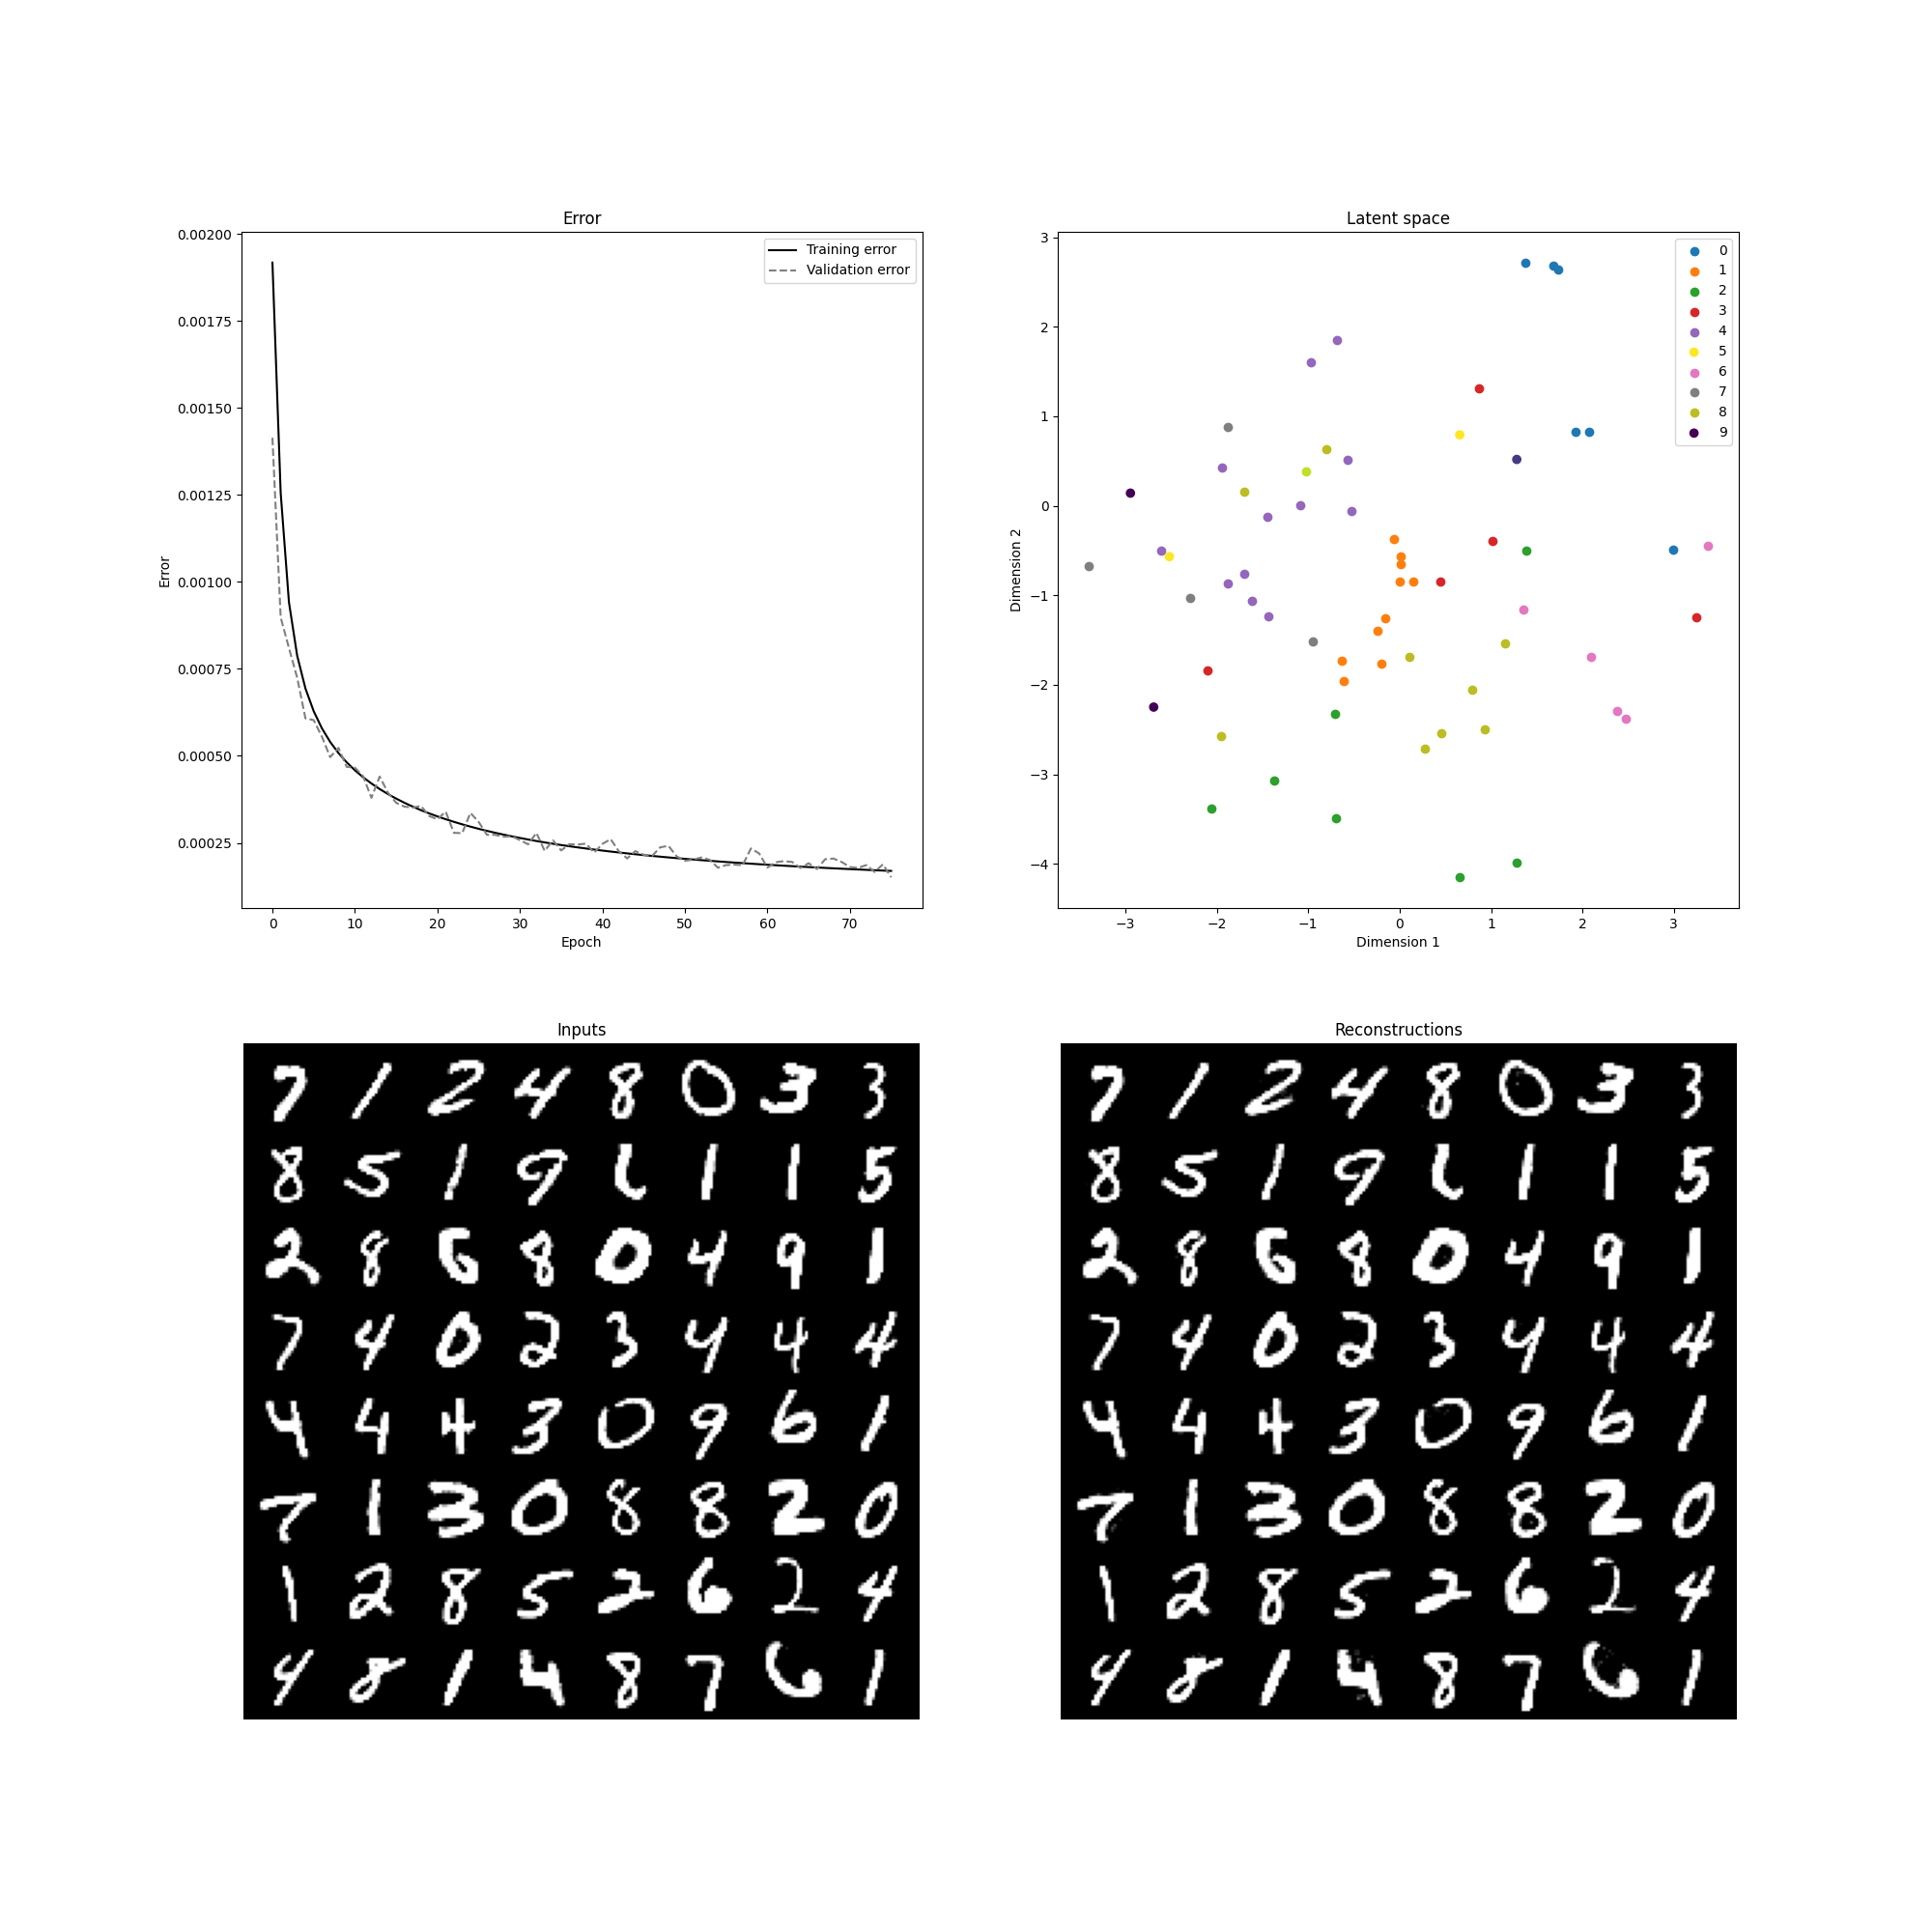

100%|██████████| 100/100 [02:26<00:00,  1.46s/it]


In [31]:
from sklearn.manifold import TSNE

classes = train_dataset['labels'].unique().tolist()
num_epochs = 100

train_loss = []
valid_loss = []

for epoch in tqdm(range(num_epochs)):
    batch_loss = []
    net.train()
    
    # Go through each batch in the training dataset using the loader
    # Note that y is not necessarily known as it is here
    for x, y in train_loader:
        
        x = x.to(device)
        
        outputs = net(x)
        x_hat = outputs['x_hat']

        # note, target is the original tensor, as we're working with auto-encoders
        loss = loss_function(x_hat, x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_loss.append(loss.item())

    train_loss.append(np.mean(batch_loss))

    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval()
        
        # Just load a single batch from the test loader
        x, y = next(iter(test_loader))
        
        x = x.to(device)
        
        outputs = net(x)

        # We save the latent variable and reconstruction for later use
        # we will need them on the CPU to plot
        x_hat = outputs['x_hat']
        z = outputs['z'].cpu().numpy()

        loss = loss_function(x_hat, x)

        valid_loss.append(loss.item())
    
    if epoch == 0:
        continue

    elif epoch % 25 == 0:

        model.replay_batch(
            x, 
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )
        img = model.preds[-1]

        model.replay_batch(
            x_hat, 
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )
        img_hat = model.preds[-1]

        # live plotting of the trainig curves and representation
        utils.plot_autoencoder_stats(x=img,
                                    x_hat=img_hat,
                                    z=z,
                                    y=y,
                                    train_loss=train_loss,
                                    valid_loss=valid_loss,
                                    epoch=epoch,
                                    classes=classes,
                                    dimensionality_reduction_op=TSNE(n_components=2, random_state=0).fit_transform,
                                    size=size)

In [32]:
torch.save(net.state_dict(), f'models/k-sparse_AE_{dataset_name}_lr={lr}.pt')

## Evaluation

In [5]:
net = AutoEncoder(num_features=n_ec, latent_features=n_ca1, k=round(n_ca1*0.25)).to(device)
net.load_state_dict(torch.load(f'models/k-sparse_AE_{dataset_name}.pt', weights_only=True))

<All keys matched successfully>

### Generative replay

In [9]:
h = []
z = []
labels = []
for x, y in valid_loader:
    x = x.to(device)
    outputs = net(x)
    h += outputs['h'].to('cpu').tolist()
    z += outputs['z'].to('cpu').tolist()
    labels += y.tolist()
h = torch.tensor(h)    
z = torch.tensor(z)
y = torch.tensor(labels)

In [34]:
h.shape

torch.Size([9984, 1064])

(array([2.220000e+02, 4.423100e+04, 9.306148e+06, 9.511270e+05,
        2.422880e+05, 7.017300e+04, 7.749000e+03, 9.060000e+02,
        1.170000e+02, 1.500000e+01]),
 array([-0.31358835, -0.20096236, -0.08833636,  0.02428964,  0.13691562,
         0.24954161,  0.36216763,  0.47479358,  0.58741963,  0.70004559,
         0.8126716 ]),
 <BarContainer object of 10 artists>)

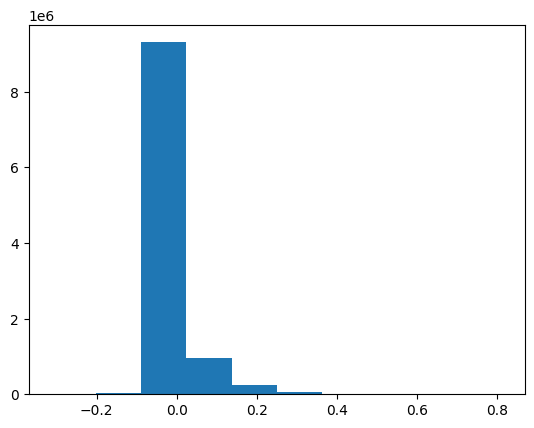

In [35]:
plt.hist(h.flatten())

(array([1.0166168e+07, 2.4009800e+05, 1.2666400e+05, 6.5865000e+04,
        1.8552000e+04, 4.3410000e+03, 9.9600000e+02, 2.4500000e+02,
        3.6000000e+01, 1.1000000e+01]),
 array([0.        , 0.06646919, 0.13293839, 0.19940758, 0.26587677,
        0.33234596, 0.39881516, 0.46528435, 0.53175354, 0.59822273,
        0.66469193]),
 <BarContainer object of 10 artists>)

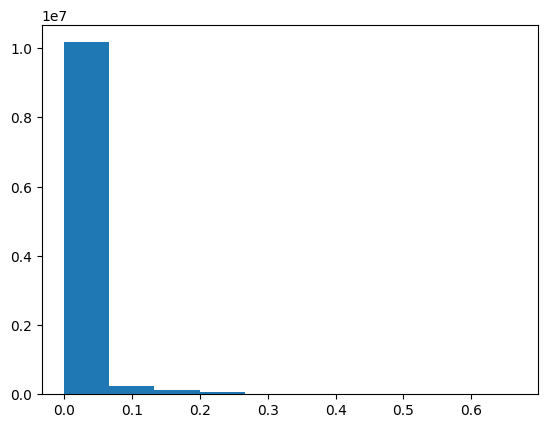

In [36]:
plt.hist(z.flatten())

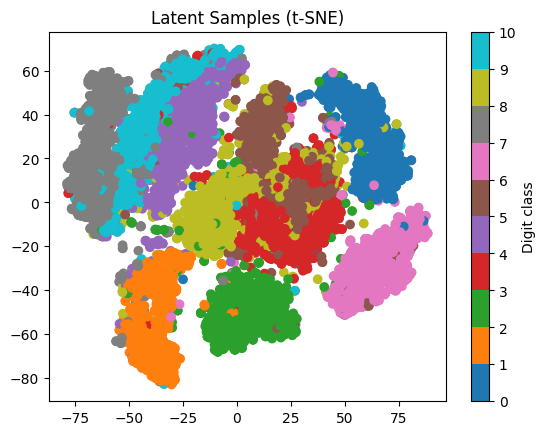

In [ ]:
import matplotlib as mpl
fig, ax = plt.subplots()
plotting.visualize_latent(ax, z, y)

n_classes = len(y.unique())
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
cmap = (mpl.colors.ListedColormap(colors))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(0, n_classes))
plt.colorbar(sm, ax=ax, ticks=np.linspace(0, n_classes, n_classes+1), label="Digit class")

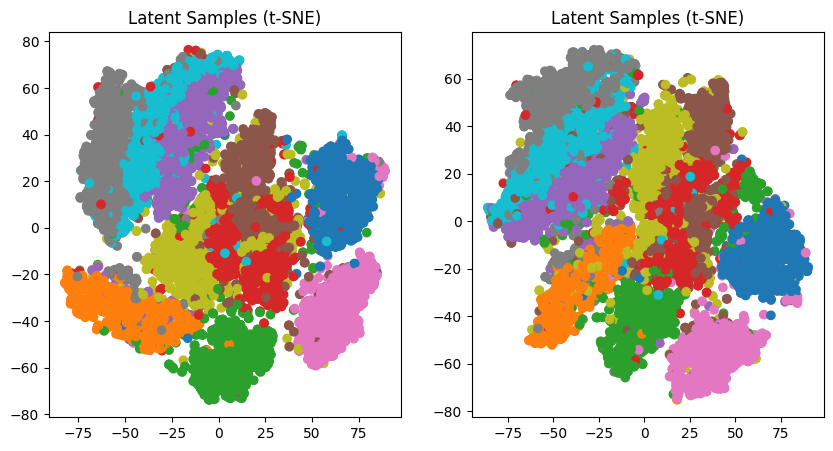

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plotting.visualize_latent(axes[0], z, y)
plotting.visualize_latent(axes[1], h, y)

In [38]:
classes = np.unique(y_train)
labels = []
ec_batch_euclid = []
ec_stat = {'mu': [], 'cov': []}
with torch.no_grad():
    for i in classes:
        indices = np.where(y == i)[0]
        h_train = np.array(h)[indices]
        h_sample = pcn.utils.sample_from_latent(h_train, batch_size).float()
        ca1 = net.apply_inhibition(h_sample)
        ca1 = ca1.to(device)
        ec = torch.tanh(net.decoder(ca1)).cpu()
        ec_batch_euclid.append(ec)
        labels += [i for _ in range(batch_size)]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_31152\3276850700.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  h_train = np.array(h)[indices]


(array([1.000e+01, 8.800e+01, 6.600e+02, 2.677e+03, 6.087e+03, 6.054e+03,
        2.820e+03, 6.870e+02, 1.120e+02, 5.000e+00]),
 array([-0.14862695, -0.11910533, -0.08958371, -0.06006208, -0.03054046,
        -0.00101884,  0.02850279,  0.05802441,  0.08754604,  0.11706766,
         0.14658928]),
 <BarContainer object of 10 artists>)

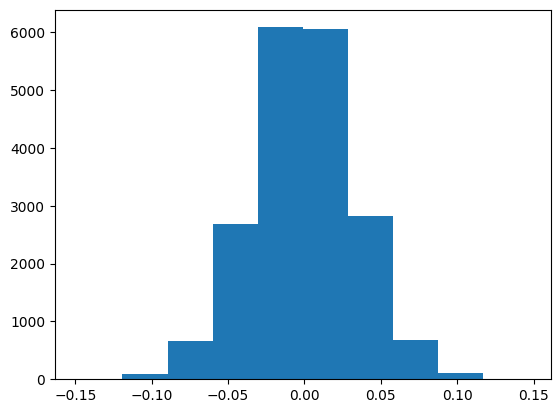

In [39]:
plt.hist(ec.flatten())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8611488..5.7826076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1168396..5.9663577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.179163..5.6304283].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9170997..5.9400887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7895385..5.350998].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4720745..5.9110413].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.230776..

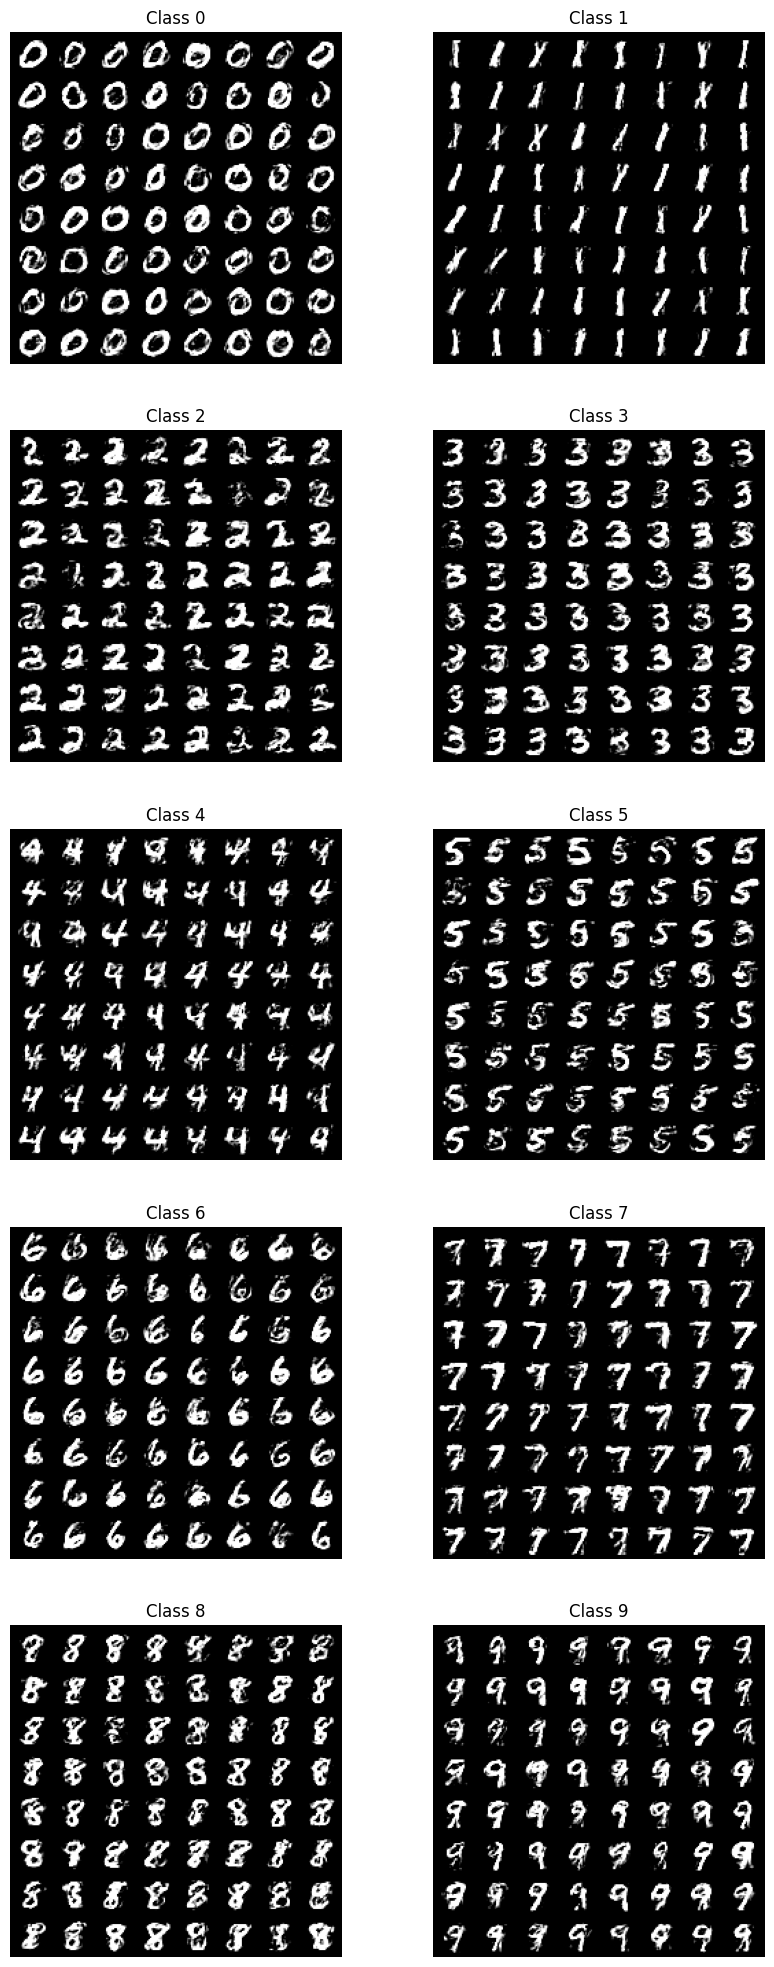

In [40]:
K = len(classes)
nrows = K//2
ncols = 2
fig1, axes = plt.subplots(nrows, ncols, figsize = (5*ncols, 5*nrows))

for k in range(K):
    label = int(labels[k*batch_size])
    batch = pcn.utils.set_tensor(ec_batch_euclid[k])
    with torch.no_grad():
        model.replay_batch(
            batch,
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )    
    i = k//2
    j = k%2
    axes[i, j].set_title(f'Class {label}')
    pcn.plotting.plot_samples(axes[i, j], model.preds[-1], size)

### Pattern completion

In [6]:
alpha = 0.5
img = train_dataset['img'][-batch_size:]
indices = pcn.utils.get_mask_indices(size, alpha)
img_half = pcn.utils.mask_image(img, indices)

In [7]:
with torch.no_grad():
    img_batch_half = pcn.utils.set_tensor(img_half)
    model.test_batch(
        img_batch_half, 
        n_iters=n_max_iters, 
        step_tolerance=step_tolerance, 
        init_std=init_std, 
        fixed_preds=fixed_preds_test
    )
    ec_half = model.mus[0]

In [8]:
ec_half = ec_half.to(device)
outputs = net(ec_half)
ec_hat = outputs['x_hat']

In [9]:
with torch.no_grad():
    model.replay_batch(
        ec_hat,
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )   
    img_hat = model.preds[-1]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3439639..5.7671757].


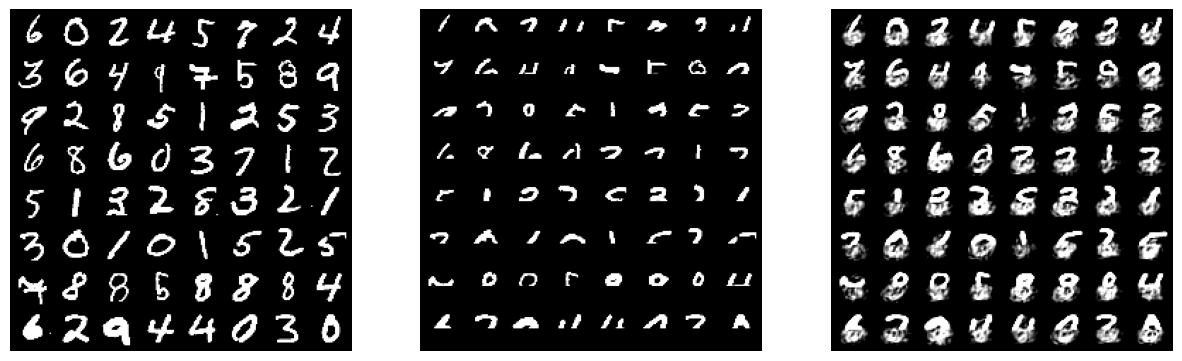

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plotting.plot_samples(axes[0], img, size)
plotting.plot_samples(axes[1], img_half, size)
plotting.plot_samples(axes[2], img_hat, size)